In [1]:
library(stats)
set.seed(12345)
Sys.time()

[1] "2026-03-23 08:09:39 UTC"

# EPL Examples

## Data Generation

I generated a synthetic population of $N$ individuals, each with a location specified by $J$ hierarchically nested levels, designed to have an average of $\mu$ individuals per location.
I represented this database as matrix $D$ with $N$ rows and $J$ columns, where row $D_i$ represented the hierarchically nested location of individual $i$.
To assign the location, for each individual $i$, for each level of the spatial hierarchy $j$, I sampled the location uniformly,  $D_{ij} \sim_{\mathcal{U}} \{0, 1, \ldots, C-1\}$ where $C = \left\lfloor \left(N/\mu\right)^{1/J} \right\rfloor$ is the number of children for every areal unit in the spatial hierarchy before level $J$.

In [2]:
N <- 1000000  # number of individuals
mu <- 100     # average population
J <- 3        # levels of hierarchy

C <- as.integer(floor((N/mu)^(1/J)))

df <- data.frame(
  area_0 = sample(0:(C-1), N, replace = TRUE),
  area_1 = sample(0:(C-1), N, replace = TRUE),
  area_2 = sample(0:(C-1), N, replace = TRUE),
  weight = 1
)
cat("C =", C, "\n")
cat("dim(df) =", dim(df), "\n")
head(df)

C = 21 


dim(df) = 1000000 4 


,area_0,area_1,area_2,weight
,<int>,<int>,<int>,<dbl>
1,13,16,1,1
2,18,17,5,1
3,15,13,8,1
4,10,2,10,1
5,1,13,3,1
6,10,19,1,1


## Exact counts

To find the exact total count (TC) for each location at any level of the spatial hierarchy, I grouped the database $D$ by spatial area and counted how many individuals were in each areal unit:
$$
\mathrm{TC}_{j_1, j_2, \ldots, j_{J'}} = \sum_i \mathbf{1}\left[
D_{i,1} = j_1 \wedge 
D_{i,2} = j_2 \wedge 
\ldots
D_{i,J'} = j_{J'}
\right].
$$

In [3]:
exact_counts <- aggregate(weight ~ area_0 + area_1 + area_2, data = df, FUN = sum)
exact_counts <- exact_counts[order(exact_counts$area_0, exact_counts$area_1, exact_counts$area_2), ]
rownames(exact_counts) <- NULL

cat("Number of area combinations:", nrow(exact_counts), "\n")
cat("Summary of exact counts:\n")
summary(exact_counts$weight)
head(exact_counts, 8)

Number of area combinations: 9261 


Summary of exact counts:


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
     72     101     108     108     115     154 

,area_0,area_1,area_2,weight
,<int>,<int>,<int>,<dbl>
1,0,0,0,107
2,0,0,1,87
3,0,0,2,87
4,0,0,3,115
5,0,0,4,120
6,0,0,5,107
7,0,0,6,111
8,0,0,7,95


## Geometric Mechanism:

To generate $\epsilon$-DP counts from exact counts, I used the geometric mechanism to add noise to the exact counts for the most fine-grained areas in the spatial hierarchy (abbreviated GDPC for geometric DP count):
$$
\mathrm{GDPC}_{j_1, j_2, \ldots, j_{J}} = \mathrm{TC}_{j_1, j_2, \ldots, j_{J}} + X_{j_1, j_2, \ldots, j_{J}},
$$
where $X_{j_1, j_2, \ldots, j_{J}} \sim G(\epsilon)$ is drawn from a two-tailed geometric distribution with parameter $\epsilon$, defined by the following equation
$$\Pr[G(z)=k] = \frac{(1 - \exp(-z))\exp(-z|k|)}{1 + \exp(-z)}.$$

In [4]:
GDPC <- function(epsilon, counts) {
  z <- as.numeric(epsilon)
  p <- 1 - exp(-z)  # success probability for R's rgeom
  n <- length(counts)
  errors <- rgeom(n, p) - rgeom(n, p)
  dp_counts <- counts + errors
  return(dp_counts)
}

epsilon <- "0.1"
gdp_counts <- GDPC(epsilon, exact_counts$weight)
cat("First few DP counts vs exact counts:\n")
head(data.frame(exact = exact_counts$weight, dp = gdp_counts))

First few DP counts vs exact counts:


,exact,dp
,<dbl>,<dbl>
1,107,96
2,87,83
3,87,97
4,115,139
5,120,134
6,107,81


## Raked Mechanism:

To capture a key element of the TopDown approach developed for the 2020 US Census, I also generated $\epsilon$-DP counts from exact counts hierarchically, by "raking" the noisy counts at each level to sum to the noisy count from the level above.

For level $J'$ of the spatial hierarchy, I first calculated noisy counts using only a $1/(J+1)$ portion of the total privacy budget $\epsilon$, then scaled ("raked") the noisy counts within each spatial area so that they sum to the raked count from the level above.

In [5]:
RDPC <- function(epsilon, exact_counts_df, df_data) {
  z <- as.numeric(epsilon) / (J + 1)
  p <- 1 - exp(-z)
  
  # Noisy count for whole population
  exact_count_0 <- sum(df_data$weight)
  error_0 <- rgeom(1, p) - rgeom(1, p)
  noisy_count_0 <- exact_count_0 + error_0
  
  # Level 0: group by area_0
  counts_1 <- aggregate(weight ~ area_0, data = df_data, FUN = sum)
  counts_1 <- counts_1[order(counts_1$area_0), ]
  n1 <- nrow(counts_1)
  noisy_1 <- counts_1$weight + rgeom(n1, p) - rgeom(n1, p)
  raked_1 <- noisy_1 * (noisy_count_0 / sum(noisy_1))
  names(raked_1) <- counts_1$area_0
  
  # Level 1: group by area_0, area_1
  counts_2 <- aggregate(weight ~ area_0 + area_1, data = df_data, FUN = sum)
  counts_2 <- counts_2[order(counts_2$area_0, counts_2$area_1), ]
  n2 <- nrow(counts_2)
  noisy_2 <- counts_2$weight + rgeom(n2, p) - rgeom(n2, p)
  raked_2 <- numeric(n2)
  for (a0 in unique(counts_2$area_0)) {
    idx <- counts_2$area_0 == a0
    s <- noisy_2[idx]
    raked_2[idx] <- s * (raked_1[as.character(a0)] / sum(s))
  }
  
  # Level 2: full detail
  n3 <- nrow(exact_counts_df)
  noisy_3 <- exact_counts_df$weight + rgeom(n3, p) - rgeom(n3, p)
  raked_3 <- numeric(n3)
  # Create a lookup key for raked_2
  key_2 <- paste(counts_2$area_0, counts_2$area_1, sep = "_")
  names(raked_2) <- key_2
  
  for (i in seq_len(nrow(counts_2))) {
    a0 <- counts_2$area_0[i]
    a1 <- counts_2$area_1[i]
    idx <- exact_counts_df$area_0 == a0 & exact_counts_df$area_1 == a1
    s <- noisy_3[idx]
    k <- paste(a0, a1, sep = "_")
    raked_3[idx] <- s * (raked_2[k] / sum(s))
  }
  
  return(raked_3)
}

rdp_counts <- RDPC(epsilon, exact_counts, df)
cat("First few raked DP counts vs exact counts:\n")
head(data.frame(exact = exact_counts$weight, rdp = round(rdp_counts, 2)))

First few raked DP counts vs exact counts:


,exact,rdp
,<dbl>,<dbl>
1,107,76.61
2,87,104.68
3,87,81.92
4,115,319.34
5,120,39.44
6,107,76.61


# Average-of-Multiple-Geometric Mechanism:

As a comparison, I also used a mechanism which produced an average of multiple noisy measurements that is provably $\epsilon$-DP. I split the total privacy budget equally into $P$ parts, then used each portion to run the geometric mechanism, and obtained the ADPC from their arithmetic mean:

$$
\mathrm{ADPC}_{j_1,j_2,\ldots, j_{J}} =
\frac{1}{P}\sum_{p=1}^P
\mathrm{GDPC}_{j_1, j_2, \ldots, j_{J}}^p
$$

In [6]:
ADPC <- function(epsilon, P, counts) {
  z <- as.numeric(epsilon) / P
  dp_counts <- rep(0, length(counts))
  for (p_i in 1:P) {
    dp_counts <- dp_counts + GDPC(z, counts)
  }
  dp_counts <- dp_counts / P
  return(dp_counts)
}

epsilon <- "0.1"
adp_counts <- ADPC(epsilon, 4, exact_counts$weight)
cat("First few averaged DP counts vs exact counts:\n")
head(data.frame(exact = exact_counts$weight, adp = adp_counts))

First few averaged DP counts vs exact counts:


,exact,adp
,<dbl>,<dbl>
1,107,96.75
2,87,128.50
3,87,112.25
4,115,80.75
5,120,156.25
6,107,64.75


# Direct, general search for empirical privacy loss

The most direct way to empirically investigate the privacy loss is to search for databases $D$ and $D'$ that differ on a single row and an event $E$ that can serve as a witness to the gap between $\Pr[\mathcal{A}(D) \in E]$ and $\Pr[\mathcal{A}(D') \in E]$.

_Simple estimate:_ Run the mechanisms repeatedly with $D$ and $D'$, estimate probabilities, and compute log-ratios.

**Note:** The direct simulation with 500 replicates is computationally expensive in R due to the RDPC raking loops. We use 100 replicates here (reduce R_reps for faster execution).

In [7]:
R_reps <- 100  # replicates (reduced from 500 for R performance)

perturbed_counts <- exact_counts
perturbed_counts$weight[1] <- perturbed_counts$weight[1] - 1
idx_pert <- min(1001, nrow(perturbed_counts))
perturbed_counts$weight[idx_pert] <- perturbed_counts$weight[idx_pert] + 1

P <- J + 1

dpc <- list()

cat("Running", R_reps, "replicates (this may take a few minutes)...\n")
t0 <- proc.time()

for (r in 1:R_reps) {
  dpc[[paste("GDPC", r, "D", sep = "_")]] <- GDPC(epsilon, exact_counts$weight)
  dpc[[paste("GDPC", r, "Dp", sep = "_")]] <- GDPC(epsilon, perturbed_counts$weight)
  
  dpc[[paste("RDPC", r, "D", sep = "_")]] <- RDPC(epsilon, exact_counts, df)
  dpc[[paste("RDPC", r, "Dp", sep = "_")]] <- RDPC(epsilon, perturbed_counts, df)
  
  dpc[[paste("ADPC", r, "D", sep = "_")]] <- ADPC(epsilon, P, exact_counts$weight)
  dpc[[paste("ADPC", r, "Dp", sep = "_")]] <- ADPC(epsilon, P, perturbed_counts$weight)
}

elapsed <- (proc.time() - t0)["elapsed"]
cat("Done in", round(elapsed, 1), "seconds\n")

Running 100 replicates (this may take a few minutes)...


Done in 133.5 seconds


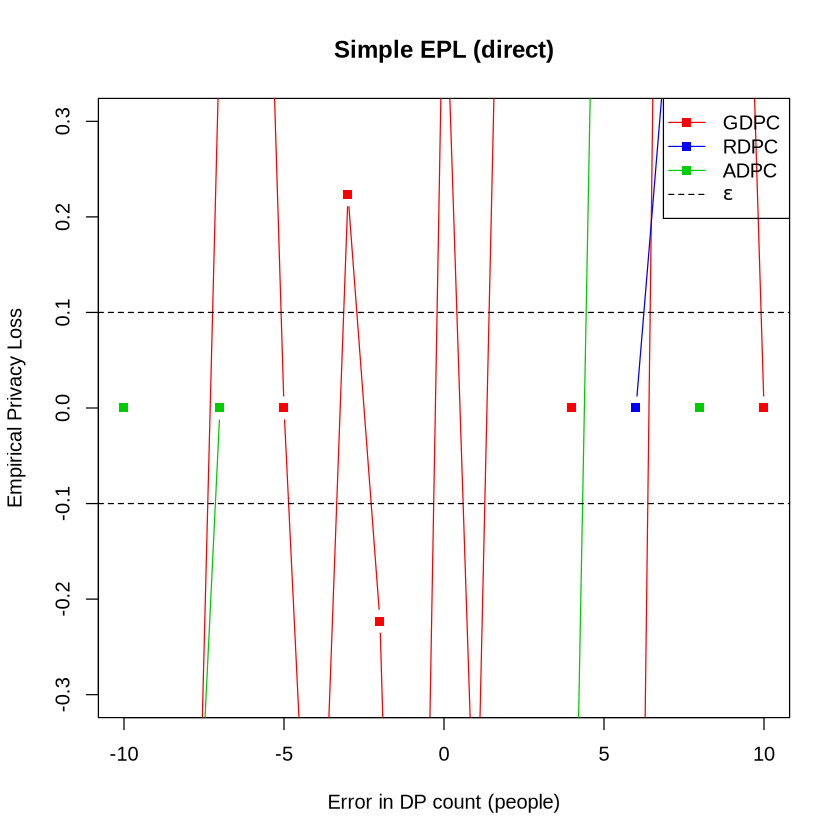

In [8]:
simple_epl <- function(dpc, method, exact_w, K, R_reps) {
  dpc_D <- sapply(1:R_reps, function(r) dpc[[paste(method, r, "D", sep = "_")]][1])
  dpc_Dp <- sapply(1:R_reps, function(r) dpc[[paste(method, r, "Dp", sep = "_")]][1])
  
  ks <- (-K):K
  epl <- numeric(length(ks))
  for (i in seq_along(ks)) {
    k <- ks[i]
    p_D <- mean(round(dpc_D - exact_w[1]) == k)
    p_Dp <- mean(round(dpc_Dp - exact_w[1]) == k)
    epl[i] <- log(p_D / p_Dp)
  }
  return(data.frame(k = ks, epl = epl))
}

eps_val <- as.numeric(epsilon)
colors <- c("red", "blue", "green3")
methods <- c("GDPC", "RDPC", "ADPC")

plot(NULL, xlim = c(-10, 10), ylim = c(-0.3, 0.3),
     xlab = "Error in DP count (people)",
     ylab = "Empirical Privacy Loss",
     main = "Simple EPL (direct)")

for (i in seq_along(methods)) {
  res <- simple_epl(dpc, methods[i], exact_counts$weight, 10, R_reps)
  lines(res$k, res$epl, type = "b", col = colors[i], pch = 15)
}

abline(h = eps_val, lty = 2, col = "black")
abline(h = -eps_val, lty = 2, col = "black")
legend("topright", legend = c(methods, expression(epsilon)),
       col = c(colors, "black"), lty = c(1, 1, 1, 2), pch = c(15, 15, 15, NA))

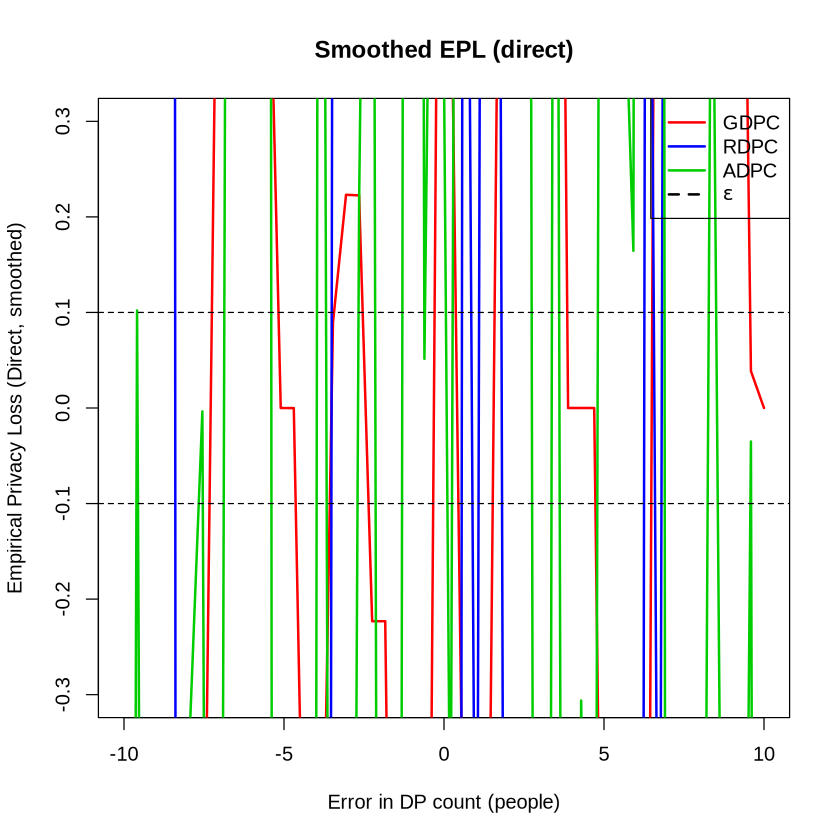

In [9]:
smoothed_epl <- function(dpc, method, exact_w, K, bw, R_reps) {
  dpc_D <- sapply(1:R_reps, function(r) dpc[[paste(method, r, "D", sep = "_")]][1])
  dpc_Dp <- sapply(1:R_reps, function(r) dpc[[paste(method, r, "Dp", sep = "_")]][1])
  
  error_D <- dpc_D - exact_w[1]
  error_Dp <- dpc_Dp - exact_w[1]
  
  k_array <- seq(-K, K, length.out = 50)
  kde_D <- density(error_D, bw = bw, n = 512, from = -K, to = K)
  kde_Dp <- density(error_Dp, bw = bw, n = 512, from = -K, to = K)
  
  p_D <- approx(kde_D$x, kde_D$y, xout = k_array)$y
  p_Dp <- approx(kde_Dp$x, kde_Dp$y, xout = k_array)$y
  
  epl <- log(p_D / p_Dp)
  return(data.frame(k = k_array, epl = epl))
}

plot(NULL, xlim = c(-10, 10), ylim = c(-0.3, 0.3),
     xlab = "Error in DP count (people)",
     ylab = "Empirical Privacy Loss (Direct, smoothed)",
     main = "Smoothed EPL (direct)")

for (i in seq_along(methods)) {
  res <- smoothed_epl(dpc, methods[i], exact_counts$weight, 10, 0.15, R_reps)
  lines(res$k, res$epl, col = colors[i], lwd = 2)
}

abline(h = eps_val, lty = 2, col = "black")
abline(h = -eps_val, lty = 2, col = "black")
legend("topright", legend = c(methods, expression(epsilon)),
       col = c(colors, "black"), lty = c(1, 1, 1, 2), lwd = 2)

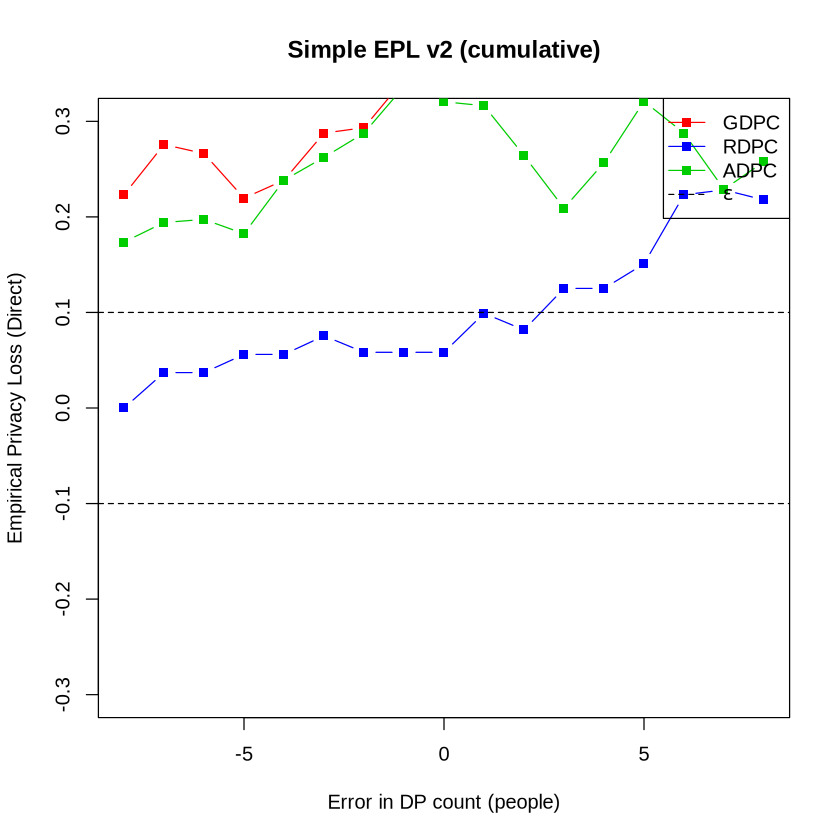

In [10]:
simple_epl_2 <- function(dpc, method, exact_w, K, R_reps) {
  dpc_D <- sapply(1:R_reps, function(r) dpc[[paste(method, r, "D", sep = "_")]][1])
  dpc_Dp <- sapply(1:R_reps, function(r) dpc[[paste(method, r, "Dp", sep = "_")]][1])
  
  ks <- (-K):K
  epl <- numeric(length(ks))
  for (i in seq_along(ks)) {
    k <- ks[i]
    p_D <- mean(round(dpc_D - exact_w[1]) >= k)
    p_Dp <- mean(round(dpc_Dp - exact_w[1]) >= k)
    epl[i] <- log(p_D / p_Dp)
  }
  return(data.frame(k = ks, epl = epl))
}

plot(NULL, xlim = c(-8, 8), ylim = c(-0.3, 0.3),
     xlab = "Error in DP count (people)",
     ylab = "Empirical Privacy Loss (Direct)",
     main = "Simple EPL v2 (cumulative)")

for (i in seq_along(methods)) {
  res <- simple_epl_2(dpc, methods[i], exact_counts$weight, 8, R_reps)
  lines(res$k, res$epl, type = "b", col = colors[i], pch = 15)
}

abline(h = eps_val, lty = 2, col = "black")
abline(h = -eps_val, lty = 2, col = "black")
legend("topright", legend = c(methods, expression(epsilon)),
       col = c(colors, "black"), lty = c(1, 1, 1, 2), pch = c(15, 15, 15, NA))

# Less-obvious estimate:

Because of the special structure of count queries, there is a way to avoid re-running the DP algorithm repeatedly. If the difference between the DP count and the exact count was identically distributed for all areal units, then we can use the residuals for all areal units to estimate the error distribution with much higher precision, from a single run.

We estimate $\log \hat{p}(k) / \hat{p}(k+1)$ using Gaussian kernel density smoothing to reduce noise in the empirical privacy loss bounds.

In [11]:
empirical_privacy_loss <- function(error, bandwidth = 0.1,
                                   est_range_percentile = 99,
                                   est_range_multiplier = 1.5) {
  lb <- quantile(error, (100 - est_range_percentile) / 100)
  ub <- quantile(error, est_range_percentile / 100)
  bnd <- est_range_multiplier * max(abs(lb), abs(ub))
  
  # Ensure bin_edges span the full range of error
  err_min <- min(error)
  err_max <- max(error)
  lo <- min(-bnd, err_min - 1)
  hi <- max(bnd, err_max + 1)
  
  bin_edges <- seq(lo, hi, by = 1)
  f_empirical <- hist(error, breaks = bin_edges, plot = FALSE)$counts
  
  n_bins <- length(f_empirical)
  # Avoid division by zero
  ratio <- ifelse(f_empirical[2:n_bins] > 0,
                  f_empirical[1:(n_bins - 1)] / f_empirical[2:n_bins],
                  NA)
  
  bin_centers <- 0.5 * (bin_edges[1:(length(bin_edges) - 2)] + bin_edges[2:(length(bin_edges) - 1)])
  
  result <- data.frame(
    x = bin_centers,
    hist_val = f_empirical[1:(n_bins - 1)],
    epl_hist = log(ratio)
  )
  
  ccusum <- sum(f_empirical) - cumsum(f_empirical)
  cusum_ratio <- ifelse(ccusum[1:(n_bins - 1)] > 0,
                        ccusum[2:n_bins] / ccusum[1:(n_bins - 1)],
                        NA)
  result$epl_cusum <- log(cusum_ratio)
  
  if (all(error == 0)) {
    result$smooth_hist <- NA
    result$smooth_epl <- Inf
  } else {
    all_bin_centers <- 0.5 * (bin_edges[1:(length(bin_edges) - 1)] + bin_edges[2:length(bin_edges)])
    kde_obj <- density(error, bw = bandwidth, n = 1024,
                       from = lo, to = hi)
    f_smoothed <- length(error) * approx(kde_obj$x, kde_obj$y, xout = all_bin_centers)$y
    
    smooth_ratio <- ifelse(f_smoothed[2:n_bins] > 0,
                           f_smoothed[1:(n_bins - 1)] / f_smoothed[2:n_bins],
                           NA)
    result$smooth_hist <- f_smoothed[1:(n_bins - 1)]
    result$smooth_epl <- log(smooth_ratio)
  }
  
  # Trim to the original estimated range for display
  keep <- result$x >= -bnd & result$x <= bnd
  result <- result[keep, ]
  
  return(result)
}

In [12]:
cat("Computing EPL for multiple epsilon values...\n")
t0 <- proc.time()

bandwidth <- 0.15
est_range_percentile <- 95
est_range_multiplier <- 2.0

P <- J + 1
df_epl <- list()

for (eps in c("0.025", "0.05", "0.1")) {
  gdp_c <- GDPC(eps, exact_counts$weight)
  df_epl[[eps]] <- empirical_privacy_loss(
    exact_counts$weight - gdp_c, bandwidth, est_range_percentile, est_range_multiplier)
  
  rdp_c <- RDPC(eps, exact_counts, df)
  df_epl[[paste0(eps, "_raked")]] <- empirical_privacy_loss(
    exact_counts$weight - rdp_c, bandwidth, est_range_percentile, est_range_multiplier)
  
  adp_c <- ADPC(eps, P, exact_counts$weight)
  df_epl[[paste0(eps, "_averaged")]] <- empirical_privacy_loss(
    exact_counts$weight - adp_c, bandwidth, est_range_percentile, est_range_multiplier)
}

elapsed <- (proc.time() - t0)["elapsed"]
cat("Done in", round(elapsed, 1), "seconds\n")

Computing EPL for multiple epsilon values...


Done in 2.2 seconds


# Visual comparison of error and EPL

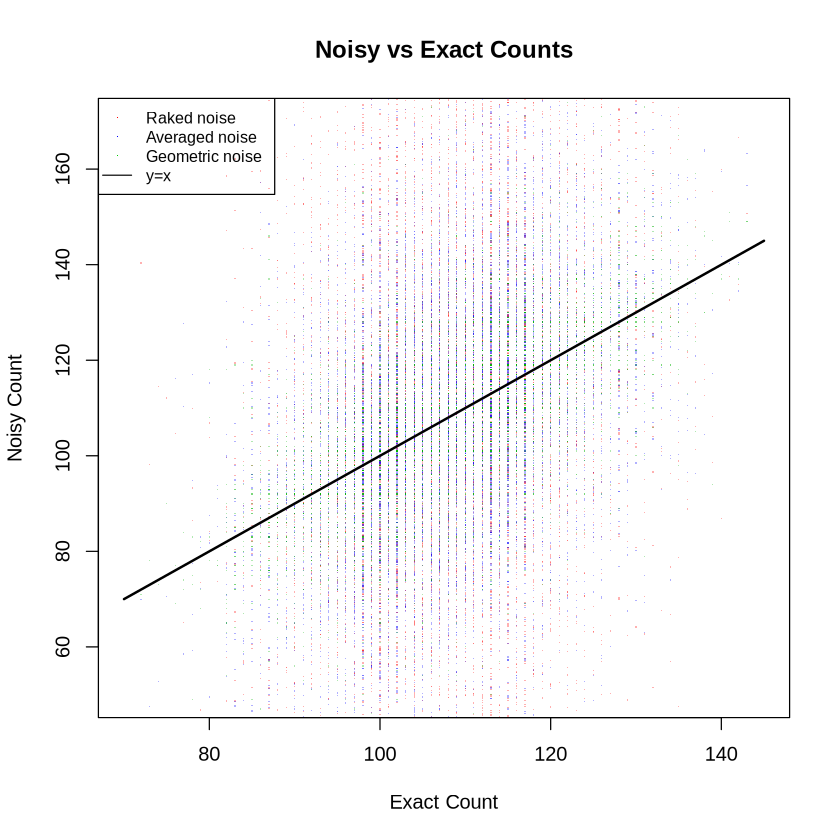

In [13]:
plot(exact_counts$weight, rdp_counts, pch = ".", col = rgb(1, 0, 0, 0.3),
     xlab = "Exact Count", ylab = "Noisy Count",
     xlim = c(70, 145), ylim = c(50, 170),
     main = "Noisy vs Exact Counts")
points(exact_counts$weight, adp_counts, pch = ".", col = rgb(0, 0, 1, 0.3))
points(exact_counts$weight, gdp_counts, pch = ".", col = rgb(0, 0.7, 0, 0.3))
lines(c(70, 145), c(70, 145), col = "black", lwd = 2)
legend("topleft", legend = c("Raked noise", "Averaged noise", "Geometric noise", "y=x"),
       col = c("red", "blue", "green3", "black"),
       pch = c(46, 46, 46, NA), lty = c(NA, NA, NA, 1), cex = 0.8)

In [14]:
my_clean <- function(eps) {
  if (grepl("_", eps)) {
    return(gsub("_", ", ", eps))
  } else {
    return(paste0(eps, ", geometric noise"))
  }
}

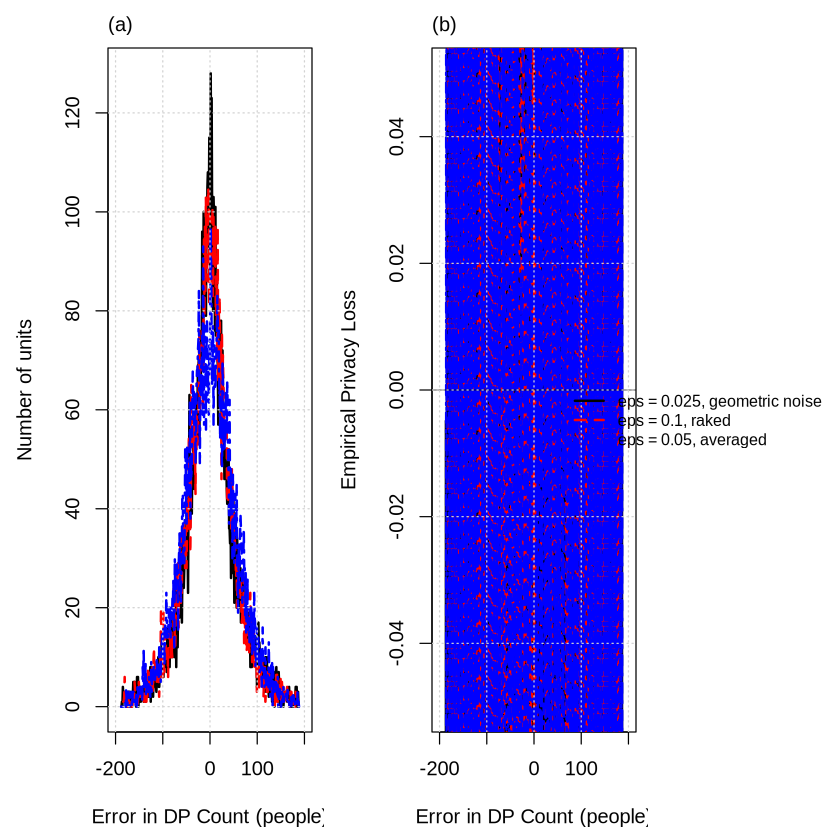

In [15]:
par(mfrow = c(1, 2), mar = c(4.5, 4.5, 2, 0.5), oma = c(0, 0, 0, 8))

xlim_val <- 200
eps_keys <- c("0.025", "0.1_raked", "0.05_averaged")
line_types <- c(1, 2, 4)
colors_plot <- c("black", "red", "blue")

# Panel (a): Error histogram
ymax <- max(sapply(eps_keys, function(e) max(df_epl[[e]]$hist_val, na.rm = TRUE)))
plot(NULL, xlim = c(-xlim_val, xlim_val), ylim = c(0, ymax),
     xlab = "Error in DP Count (people)", ylab = "Number of units")
mtext("(a)", side = 3, adj = 0, line = 0.5)
for (i in seq_along(eps_keys)) {
  d <- df_epl[[eps_keys[i]]]
  lines(d$x, d$hist_val, lty = line_types[i], lwd = 2, col = colors_plot[i])
}
grid()

# Panel (b): Smoothed EPL
plot(NULL, xlim = c(-xlim_val, xlim_val), ylim = c(-0.05, 0.05),
     xlab = "Error in DP Count (people)", ylab = "Empirical Privacy Loss")
mtext("(b)", side = 3, adj = 0, line = 0.5)
for (i in seq_along(eps_keys)) {
  d <- df_epl[[eps_keys[i]]]
  lines(d$x, d$smooth_epl, lty = line_types[i], lwd = 2, col = colors_plot[i])
}
abline(h = 0, col = "black", lwd = 0.5)
grid()

# Legend in outer margin
par(fig = c(0, 1, 0, 1), oma = c(0, 0, 0, 0), mar = c(0, 0, 0, 0), new = TRUE)
plot(0, 0, type = "n", bty = "n", xaxt = "n", yaxt = "n")
legend("right",
       legend = sapply(eps_keys, function(e) paste("eps =", my_clean(e))),
       lty = line_types, lwd = 2, col = colors_plot, cex = 0.8, bty = "n")

In [16]:
Sys.time()

[1] "2026-03-23 08:11:58 UTC"